# Part 8: Hierarchical/Mixed-Effect Model Inference

A type of model that is common in practice but tricky to implement are mixed-effect state space models, which allow individuals to posess their own parameters, derived from a local or global prior. These types of models are expressible in `dynestyx` using its `plate` primitive. In this tutorial, we implement a simple trajectory-level Ornstein-Uhlenbeck process, where each trajectory has a different mean.


## The Goal

One natural modeling choice that turns out to be somewhat difficult to implement is **hierarchical inference** for dynamical systems, sometimes called mixed-effect state space models. These may arise in a variety of settings, but one that's easy to imagine are in medical studies: parameters may be pooled at a global level via a prior $p(\theta_\text{global})$, but individual patients still posses their own distinct parameters, $\theta_i \sim p(\theta_\text{global})$. To further complicate things, there may be multiple levels of hierarchy -- for example, with heterogenous subpopulations.

Our goal in this tutorial is to write this type of hierarchical dynamical model; to do so, we introduce the final primitive of `dynestyx`, the `plate`. This plate functions a lot like a `numpyro.plate`, but includes some different implementation details to accomodate dynamical systems. Let's first refresh how plates work in NumPyro.

## Primer: Plates in NumPyro

Plates are a concept present generally in the Pyro family of probabilistic programming languages, and allow you to express conditional independence (a la a Bayesian plate diagram). Take for example the following 

$$
\begin{array}{lll}
    &\mu_{\text{global}} &\sim \mathcal{N}(0.0, 2.0^2) & \\ 
    &\mu_i \,|\, \mu_{\text{global}} &\stackrel{\mathrm{iid}}{\sim} \mathcal{N}(\mu_{\text{global}}, 0.5^2) \qquad &(i=1, \dots, N) \\
    &y_i \,|\, \mu_i &\sim \mathcal{N}(\mu_i, 0.1^2) \qquad &(i = 1, \dots, N).
\end{array}
$$

The way to write this model in NumPyro is with a `numpyro.plate` statement, which automatically vectorizes all quantities to the correct shape:

In [1]:
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist


def hierarchical_numpyro_model(ys=None, N=None):
    if ys is not None:
        if N is not None:
            assert len(ys) == N
        N = len(ys)

    mu_global = numpyro.sample("mu_global", dist.Normal(0.0, 0.5))
    with numpyro.plate("N", N):
        mu_i = numpyro.sample("mu_i", dist.Normal(mu_global, 0.5))
        numpyro.sample("y_i", dist.Normal(mu_i, 0.1), obs=ys)

This is consistent with all other NumPyro operations: we can generate data with `predictive`, or do inference with `NUTS`, etc.:

sample: 100%|██████████| 2000/2000 [00:00<00:00, 2836.84it/s, 7 steps of size 6.05e-01. acc. prob=0.91]


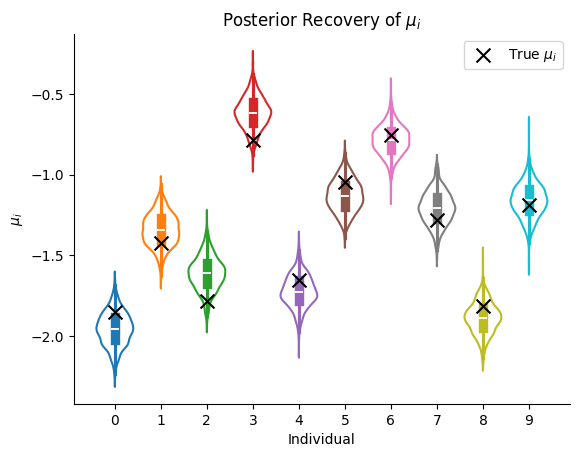

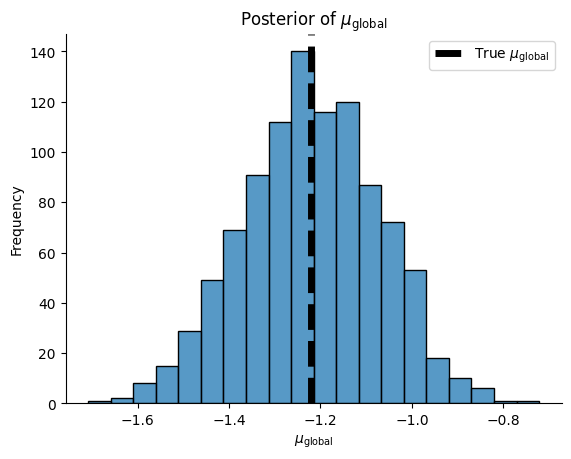

In [2]:
from numpyro.infer import NUTS, MCMC, Predictive
import seaborn as sns
import matplotlib.pyplot as plt

# Generate data with predictive
predictive = Predictive(hierarchical_numpyro_model, num_samples=1)
synthetic_data = predictive(jr.PRNGKey(0), N=10)

# Infer mu_i and mu_global with NUTS
nuts_kernel = NUTS(hierarchical_numpyro_model)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=1000)
mcmc.run(jr.PRNGKey(0), ys=synthetic_data["y_i"].squeeze())

# Plot the posterior distribution of mu_i and mu_global
sns.violinplot(data=mcmc.get_samples()["mu_i"], fill=False)
plt.scatter(
    range(10),
    synthetic_data["mu_i"],
    color="black",
    zorder=10,
    marker="x",
    s=100,
    label=r"True $\mu_i$",
)
sns.despine()
plt.title(r"Posterior Recovery of $\mu_i$")
plt.xlabel("Individual")
plt.ylabel(r"$\mu_i$")
plt.legend()
plt.show()

# Plot the posterior of mu_global
sns.histplot(mcmc.get_samples()["mu_global"], bins=20)
plt.axvline(
    synthetic_data["mu_global"],
    color="black",
    linestyle="--",
    lw=5,
    label=r"True $\mu_{\text{global}}$",
)
plt.legend()
plt.title(r"Posterior of $\mu_{\text{global}}$")
plt.xlabel(r"$\mu_{\text{global}}$")
plt.ylabel("Frequency")
sns.despine()
plt.show()

## Plates in dynestyx

Dynestyx supports hierarchical dynamical models with `dsx.plate`. We will do this by constructing a 2-dimensional with a similar hierarchical structure as above: each trajectory has a local mean $\mu_i \in \mathbb{R}^2$, and its latent state follows a coupled 2D Ornstein-Uhlenbeck process that reverts toward that mean.

We write the coupled OU process as a continuous-time LTI model,

$$
    dx_{i,t} = A (x_{i,t} - \mu_i)\,dt + L\,dW_t,
$$

where the stable matrix $A$ has off-diagonal entries, so each component affects the other's relaxation. In `LTI_continuous`, this is represented as `A @ x + b`, with `b = -A @ mu_i`. The initial-condition mean has its own hierarchy, $\mu_{0,i}$, so the starting location is distinct from the long-run OU mean $\mu_i$.

$$
\begin{array}{lll}
    &\mu_{\text{global}} &\sim \mathcal{N}(0, 0.5^2 I_2) & \\
    &\sigma &\sim \mathrm{HalfNormal}(0.4 \mathbf{1}_2) & \\
    &\mu_i \mid \mu_{\text{global}}, \sigma &\sim \mathcal{N}(\mu_{\text{global}}, \mathrm{diag}(\sigma^2)) & (i=1, \dots, N) \\
    &\mu_{0,\text{global}} &\sim \mathcal{N}(0, 0.7^2 I_2) & \\
    &\sigma_0 &\sim \mathrm{HalfNormal}(0.5 \mathbf{1}_2) & \\
    &\mu_{0,i} \mid \mu_{0,\text{global}}, \sigma_0 &\sim \mathcal{N}(\mu_{0,\text{global}}, \mathrm{diag}(\sigma_0^2)) & (i=1, \dots, N) \\
    &x_{i,0} \mid \mu_{0,i} &\sim \mathcal{N}(\mu_{0,i}, 0.15 I_2) & \\
    &dx_{i,t} &= A (x_{i,t} - \mu_i)\,dt + L\,dW_t & \\
    &y_{i,t} \mid x_{i,t} &\sim \mathcal{N}(x_{i,t}, R). &
\end{array}
$$

In [3]:
import dynestyx as dsx
from dynestyx import LTI_continuous, Simulator
from dynestyx.inference.filter_configs import ContinuousTimeKFConfig
from dynestyx.inference.filters import Filter


def hierarchical_ou_model(
    obs_times=None,
    obs_values=None,
    predict_times=None,
    N_trajectories=None,
):
    assert N_trajectories is not None, "N_trajectories must be specified"

    state_dim = 2
    A = jnp.array([[-0.8, 0.25], [-0.15, -0.6]])
    L = 0.20 * jnp.eye(state_dim)
    H = jnp.eye(state_dim)
    R = (0.08**2) * jnp.eye(state_dim)

    mu_global = numpyro.sample(
        "mu_global", dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim) * 0.5**2)
    )
    sigma = numpyro.sample(
        "sigma", dist.HalfNormal(0.4 * jnp.ones(state_dim)).to_event(1)
    )
    mu_0_global = numpyro.sample(
        "mu_0_global", dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim) * 0.7**2)
    )
    sigma_0 = numpyro.sample(
        "sigma_0", dist.HalfNormal(0.5 * jnp.ones(state_dim)).to_event(1)
    )

    with dsx.plate("N", N_trajectories):
        mu_i = numpyro.sample("mu_i", dist.MultivariateNormal(mu_global, sigma * jnp.eye(state_dim)))
        mu_0_i = numpyro.sample(
            "mu_0_i", dist.MultivariateNormal(mu_0_global, sigma_0 * jnp.eye(state_dim))
        )
        b = -jnp.einsum("ij,...j->...i", A, mu_i)

        dynamics = LTI_continuous(
            A=A,
            L=L,
            H=H,
            R=R,
            b=b,
            initial_mean=mu_0_i,
            initial_cov=0.15 * jnp.eye(state_dim),
        )

        return dsx.sample(
            "f",
            dynamics,
            obs_times=obs_times,
            obs_values=obs_values,
            predict_times=predict_times,
        )

We can generate multiple OU trajectories in one call. The simulated observations have shape `(num_samples, N_trajectories, n_simulations, T, state_dim)`, so conditioning data for inference is `synthetic_data["f_observations"][0, :, 0]`, with shape `(N_trajectories, T, state_dim)`.

In [4]:
N_trajectories = 8
predict_times = jnp.linspace(0.0, 10.0, 100)
true_params = {
    "mu_global": jnp.array([0.8, -0.4]),
    "sigma": jnp.array([0.25, 0.20]),
    "mu_0_global": jnp.array([-0.8, 0.7]),
    "sigma_0": jnp.array([0.25, 0.30]),
}

with Simulator():
    predictive = Predictive(
        hierarchical_ou_model,
        params=true_params,
        num_samples=1,
        exclude_deterministic=False,
    )
    synthetic_data = predictive(
        jr.PRNGKey(1),
        N_trajectories=N_trajectories,
        predict_times=predict_times,
    )

obs_times = predict_times
obs_values = synthetic_data["f_observations"][0, :, 0]

synthetic_data["mu_i"].shape, synthetic_data["mu_0_i"].shape, obs_values.shape

((1, 8, 2), (1, 8, 2), (8, 100, 2))

Each trajectory has a different two-dimensional OU mean and a different initial-condition mean. The dashed lines show the true long-run OU mean component $\mu_i$; the dots at `t=0` show the corresponding initial-condition prior mean $\mu_{0,i}$.

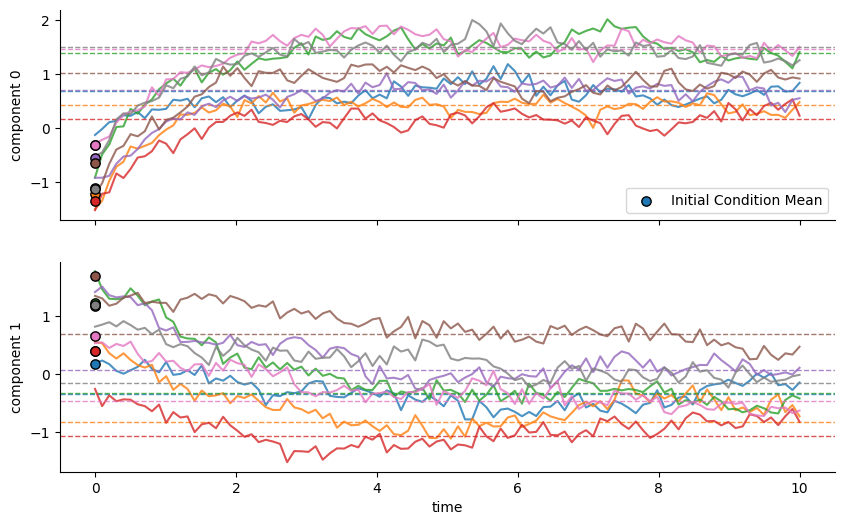

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for component, ax in enumerate(axes):
    for i in range(N_trajectories):
        color = f"C{i}"
        ax.axhline(
            synthetic_data["mu_i"][0, i, component],
            color=color,
            linestyle="--",
            lw=1,
            alpha=0.8,
        )
        ax.plot(predict_times, obs_values[i, :, component], color=color, alpha=0.8)
        ax.scatter(
            0.0,
            synthetic_data["mu_0_i"][0, i, component],
            color=color,
            edgecolor="black",
            s=45,
            zorder=5,
            label=r"Initial Condition Mean" if i == 0 and component == 0 else None,
        )
    ax.set_ylabel(f"component {component}")
axes[0].legend(loc="best")
axes[-1].set_xlabel("time")
sns.despine()
plt.show()

This coupled OU process is linear and Gaussian, so we can use the exact continuous-time Kalman filter inside NUTS. The filter computes one marginal log likelihood per plate member, and NumPyro combines those contributions for the hierarchical posterior.

In [6]:
def conditioned_hierarchical_ou_model():
    with Filter(ContinuousTimeKFConfig()):
        return hierarchical_ou_model(
            N_trajectories=N_trajectories,
            obs_times=obs_times,
            obs_values=obs_values,
        )


mcmc = MCMC(NUTS(conditioned_hierarchical_ou_model), num_warmup=100, num_samples=100)
mcmc.run(jr.PRNGKey(2))
posterior = mcmc.get_samples()

sample: 100%|██████████| 200/200 [00:08<00:00, 24.02it/s, 7 steps of size 4.08e-01. acc. prob=0.88] 


The posterior samples preserve both axes: `mu_i` and `mu_0_i` have shape `(num_samples, N_trajectories, state_dim)`. This is the main convention to keep in mind when lifting scalar hierarchical OU examples to multidimensional trajectories. In the recovery plots below, crosses mark the true long-run OU means $\mu_i$, while dots mark the true initial-condition means $\mu_{0,i}$.

In [7]:
(
    posterior["mu_global"].shape,
    posterior["sigma"].shape,
    posterior["mu_i"].shape,
    posterior["mu_0_global"].shape,
    posterior["sigma_0"].shape,
    posterior["mu_0_i"].shape,
)

((100, 2), (100, 2), (100, 8, 2), (100, 2), (100, 2), (100, 8, 2))

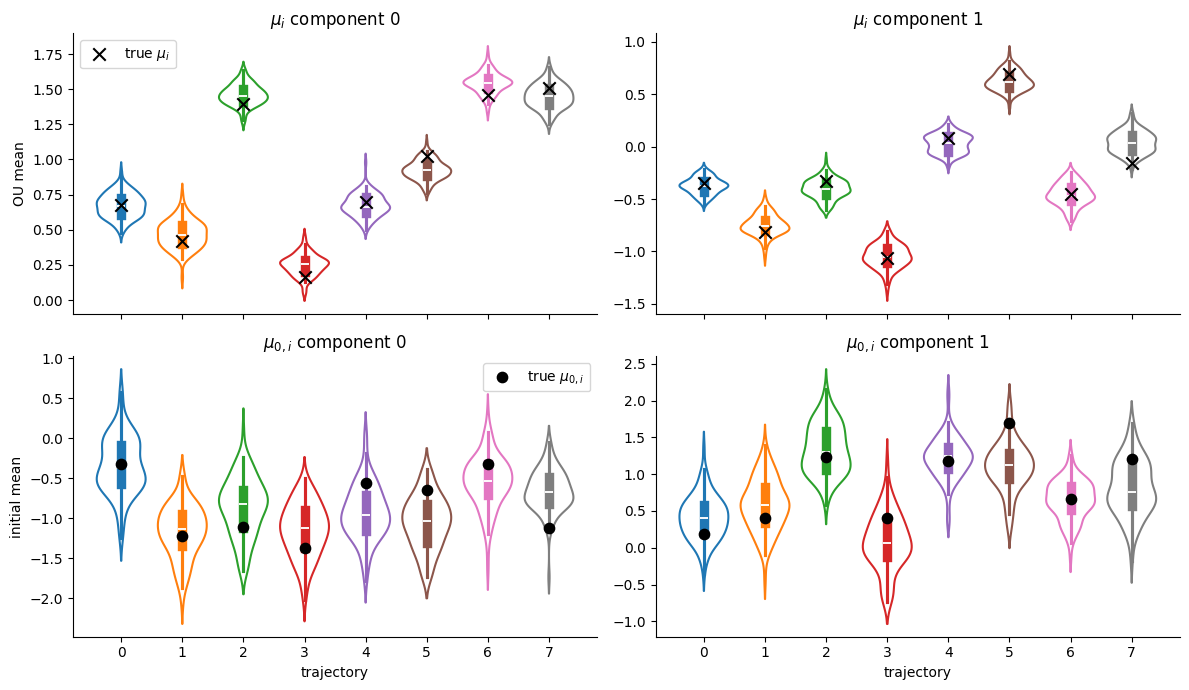

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=False)
for component in range(2):
    ax = axes[0, component]
    sns.violinplot(data=posterior["mu_i"][:, :, component], fill=False, ax=ax)
    ax.scatter(
        range(N_trajectories),
        synthetic_data["mu_i"][0, :, component],
        color="black",
        marker="x",
        s=80,
        zorder=10,
        label=r"true $\mu_i$",
    )
    ax.set_title(rf"$\mu_i$ component {component}")

    ax = axes[1, component]
    sns.violinplot(data=posterior["mu_0_i"][:, :, component], fill=False, ax=ax)
    ax.scatter(
        range(N_trajectories),
        synthetic_data["mu_0_i"][0, :, component],
        color="black",
        marker="o",
        s=55,
        zorder=10,
        label=r"true $\mu_{0,i}$",
    )
    ax.set_title(rf"$\mu_{{0,i}}$ component {component}")
    ax.set_xlabel("trajectory")
axes[0, 0].set_ylabel("OU mean")
axes[1, 0].set_ylabel("initial mean")
axes[0, 0].legend()
axes[1, 0].legend()
sns.despine()
plt.tight_layout()
plt.show()

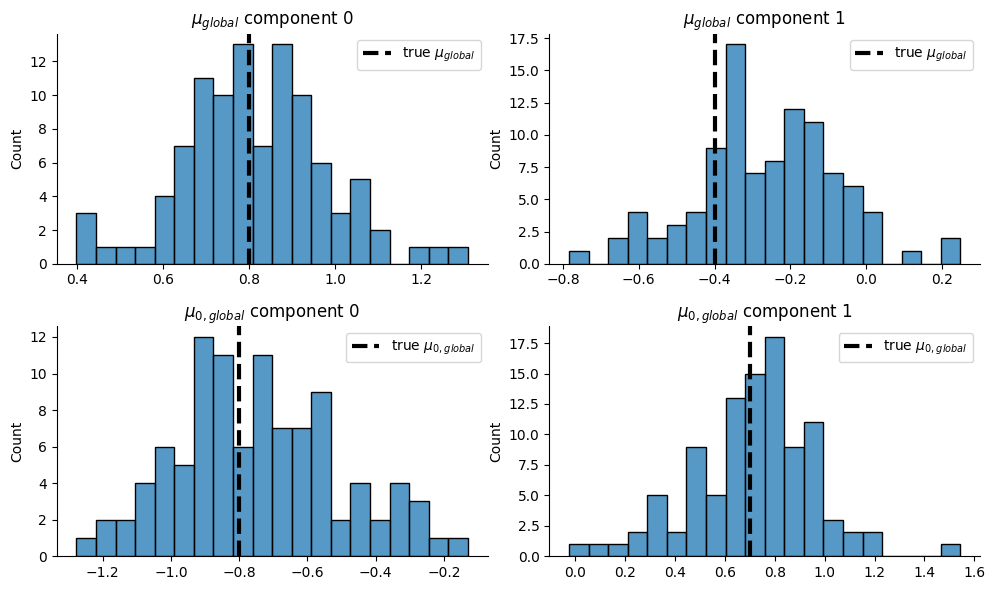

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for component in range(2):
    ax = axes[0, component]
    sns.histplot(posterior["mu_global"][:, component], bins=20, ax=ax)
    ax.axvline(
        true_params["mu_global"][component],
        color="black",
        linestyle="--",
        lw=3,
        label=r"true $\mu_{global}$",
    )
    ax.set_title(rf"$\mu_{{global}}$ component {component}")
    ax.legend()

    ax = axes[1, component]
    sns.histplot(posterior["mu_0_global"][:, component], bins=20, ax=ax)
    ax.axvline(
        true_params["mu_0_global"][component],
        color="black",
        linestyle="--",
        lw=3,
        label=r"true $\mu_{0,global}$",
    )
    ax.set_title(rf"$\mu_{{0,global}}$ component {component}")
    ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Handling Missing Observations

We can also reuse this same hierarchical OU model when some observations are missing. Here we introduce a range of missingness styles across trajectories: full blocks of missing time, single-component dropouts, and sparse intermittent gaps. For inference we route through a cuthbert-backed discrete-time EnKF by nesting `dsx.Discretizer()` inside `Filter(...)`, which allows `NaN` values in `obs_values` while keeping the same hierarchical model definition.

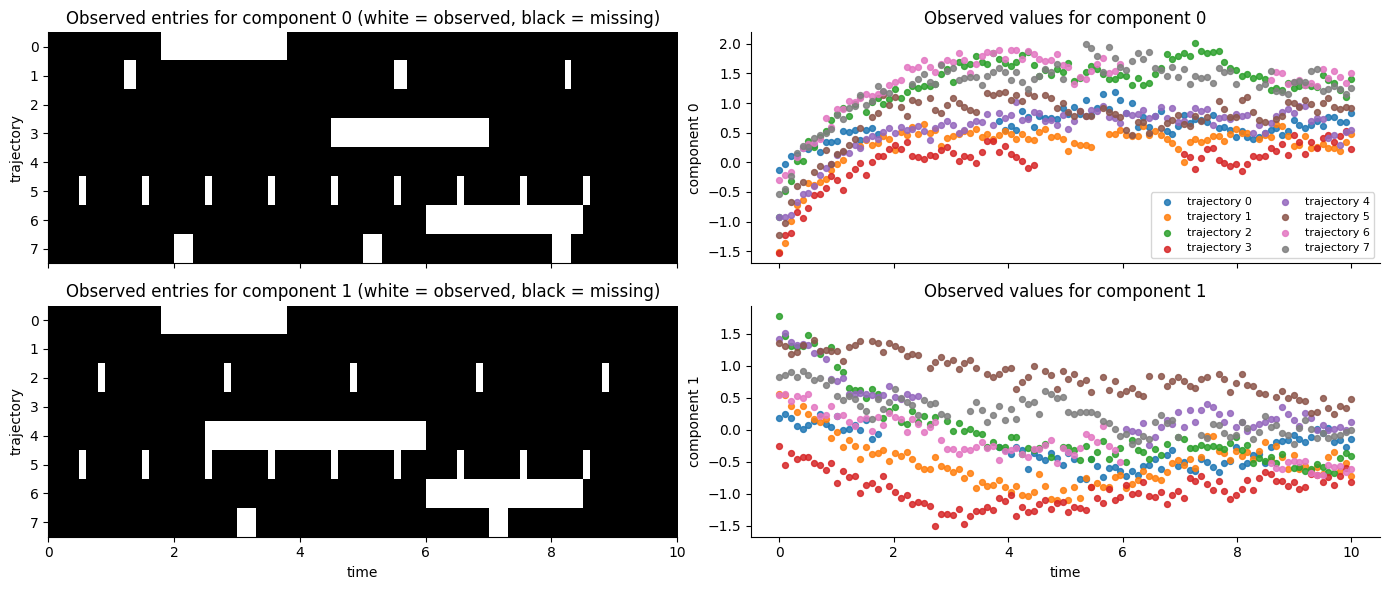

In [34]:
obs_values_missing = obs_values

obs_values_missing = obs_values_missing.at[0, 18:38, :].set(jnp.nan)
obs_values_missing = obs_values_missing.at[1, [12, 13, 55, 56, 82], 0].set(jnp.nan)
obs_values_missing = obs_values_missing.at[2, [8, 28, 48, 68, 88], 1].set(jnp.nan)
obs_values_missing = obs_values_missing.at[3, 45:70, 0].set(jnp.nan)
obs_values_missing = obs_values_missing.at[4, 25:60, 1].set(jnp.nan)
obs_values_missing = obs_values_missing.at[5, [5, 15, 25, 35, 45, 55, 65, 75, 85], :].set(jnp.nan)
obs_values_missing = obs_values_missing.at[6, 60:85, :].set(jnp.nan)
obs_values_missing = obs_values_missing.at[7, [20, 21, 22, 50, 51, 52, 80, 81, 82], 0].set(jnp.nan)
obs_values_missing = obs_values_missing.at[7, [30, 31, 32, 70, 71, 72], 1].set(jnp.nan)

import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex='col')
for component in range(2):
    mask_ax = axes[component, 0]
    scatter_ax = axes[component, 1]
    observed_mask = np.asarray(~jnp.isnan(obs_values_missing[:, :, component]))
    obs_component = np.asarray(obs_values_missing[:, :, component])

    mask_ax.imshow(
        observed_mask,
        aspect="auto",
        interpolation="nearest",
        cmap="Greys",
        extent=[predict_times[0], predict_times[-1], N_trajectories - 0.5, -0.5],
    )
    mask_ax.set_ylabel("trajectory")
    mask_ax.set_title(f"Observed entries for component {component} (white = observed, black = missing)")

    for i in range(N_trajectories):
        color = f"C{i}"
        keep = observed_mask[i]
        scatter_ax.scatter(
            np.asarray(predict_times)[keep],
            obs_component[i, keep],
            color=color,
            s=18,
            alpha=0.85,
            label=f"trajectory {i}" if component == 0 else None,
        )
    scatter_ax.set_ylabel(f"component {component}")
    scatter_ax.set_title(f"Observed values for component {component}")

axes[-1, 0].set_xlabel("time")
axes[-1, 1].set_xlabel("time")
axes[0, 1].legend(loc="best", ncol=2, fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

In [32]:
from dynestyx.inference.filter_configs import EnKFConfig


def conditioned_hierarchical_ou_missing_model():
    with Filter(filter_config=EnKFConfig(filter_source="cuthbert")):
        with dsx.Discretizer():
            return hierarchical_ou_model(
                N_trajectories=N_trajectories,
                obs_times=obs_times,
                obs_values=obs_values_missing,
            )


mcmc_missing = MCMC(
    NUTS(conditioned_hierarchical_ou_missing_model),
    num_warmup=100,
    num_samples=100,
)
mcmc_missing.run(jr.PRNGKey(3))
posterior_missing = mcmc_missing.get_samples()

/Users/levinema/Projects/research/dynestyx/dynestyx/models/core.py:228: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return StochasticContinuousTimeStateEvolution(
/Users/levinema/.local/share/uv/python/cpython-3.12.11-macos-aarch64-none/lib/python3.12/dataclasses.py:1588: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return obj.__class__(**changes)
sample: 100%|██████████| 200/200 [00:40<00:00,  4.90it/s, 15 steps of size 2.78e-01. acc. prob=0.95]


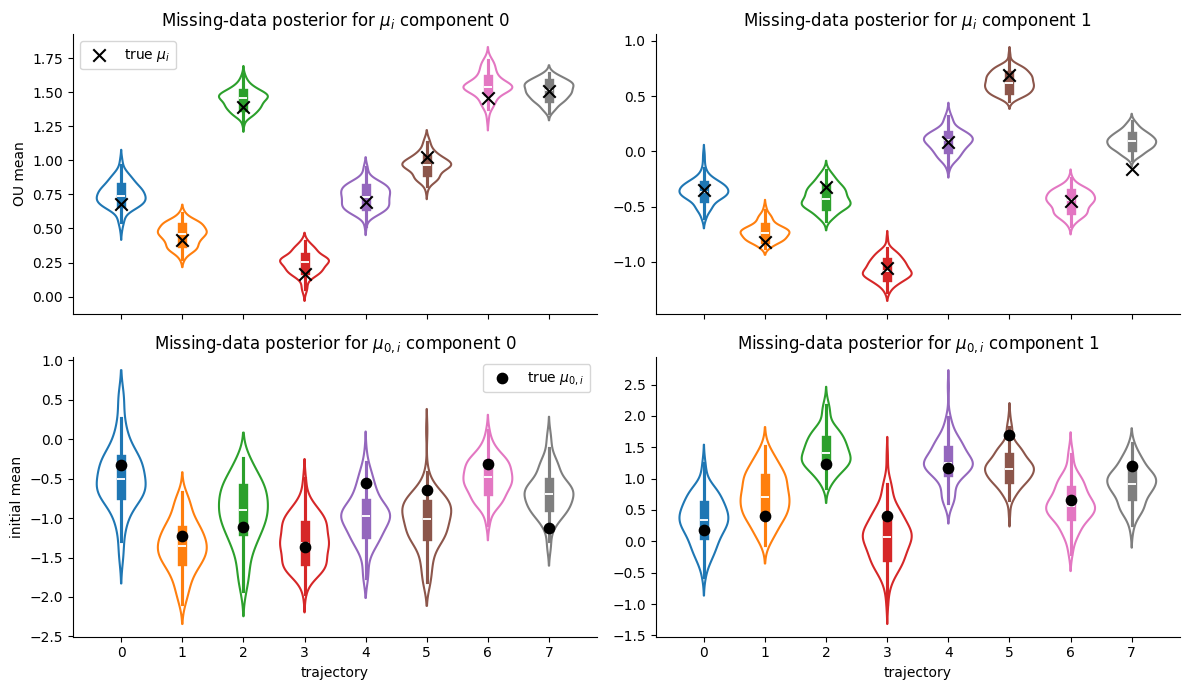

In [33]:
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=False)
for component in range(2):
    ax = axes[0, component]
    mu_i_samples = np.asarray(posterior_missing["mu_i"][:, :, component])
    true_mu_i = np.asarray(synthetic_data["mu_i"][0, :, component])
    sns.violinplot(data=mu_i_samples, fill=False, ax=ax)
    ax.scatter(
        range(N_trajectories),
        true_mu_i,
        color="black",
        marker="x",
        s=80,
        zorder=10,
        label=r"true $\mu_i$",
    )
    ax.set_title(rf"Missing-data posterior for $\mu_i$ component {component}")

    ax = axes[1, component]
    mu_0_i_samples = np.asarray(posterior_missing["mu_0_i"][:, :, component])
    true_mu_0_i = np.asarray(synthetic_data["mu_0_i"][0, :, component])
    sns.violinplot(data=mu_0_i_samples, fill=False, ax=ax)
    ax.scatter(
        range(N_trajectories),
        true_mu_0_i,
        color="black",
        marker="o",
        s=55,
        zorder=10,
        label=r"true $\mu_{0,i}$",
    )
    ax.set_title(rf"Missing-data posterior for $\mu_{{0,i}}$ component {component}")
    ax.set_xlabel("trajectory")
axes[0, 0].set_ylabel("OU mean")
axes[1, 0].set_ylabel("initial mean")
axes[0, 0].legend()
axes[1, 0].legend()
sns.despine()
plt.tight_layout()
plt.show()